<a href="https://colab.research.google.com/github/KeerthanaSistla/Emergency-alert-system/blob/main/EmergencyAlertSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 767.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 105.7 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20

DATA_DIR = "/content/drive/MyDrive/Data"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("Model/keras_model.h5", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

model.save("Model/keras_model.h5")

print("Training complete!")

Found 2800 images belonging to 7 classes.
Found 700 images belonging to 7 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9436 - loss: 0.1866 - val_accuracy: 0.9029 - val_loss: 0.2664
Epoch 15/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9445 - loss: 0.1834

44/44 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9482 - loss: 0.1739 - val_accuracy: 0.9271 - val_loss: 0.2471
Epoch 16/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9461 - loss: 0.1684 - val_accuracy: 0.9086 - val_loss: 0.2626
Epoch 17/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9546 - loss: 0.1506 - val_accuracy: 0.9129 - val_loss: 0.2476
Epoch 18/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9554 - loss: 0.1533

44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9571 - loss: 0.1450 - val_accuracy: 0.9157 - val_loss: 0.2405
Epoch 19/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9467 - loss: 0.1692

44/44 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9539 - loss: 0.1519 - val_accuracy: 0.9286 - val_loss: 0.2265
Epoch 20/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9607 - loss: 0.1397 - val_accuracy: 0.9171 - val_loss: 0.2364
Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.5643 - loss: 1.3141 - val_accuracy: 0.8986 - val_loss: 0.2681
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7396 - loss: 0.7932 - val_accuracy: 0.8943 - val_loss: 0.2825
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8075 - loss: 0.5526 - val_accuracy: 0.8914 - val_loss: 0.2679
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.8504 - loss: 0.4527 - val_accuracy: 0.8729 - val_loss: 0.3595
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.8743 - loss: 0.3595 - val_accuracy: 0.8843 - val_loss: 0.3405
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.8986 - loss: 0.3028 - val_accuracy: 0.8971 - val_loss: 0.3

Training complete!


In [10]:
loss, acc = model.evaluate(train_data)
print("Evaluation Accuracy:", acc)
print("Evaluation Loss:", loss)

44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9561 - loss: 0.1339
Evaluation Accuracy: 0.9560714364051819
Evaluation Loss: 0.13386963307857513


In [11]:
test_loss, test_acc = model.evaluate(val_data)
print("Evaluation Accuracy (using val_data):", test_acc)
print("Evaluation Loss:", test_loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9014 - loss: 0.2770
Evaluation Accuracy (using val_data): 0.9014285802841187
Evaluation Loss: 0.2769779562950134


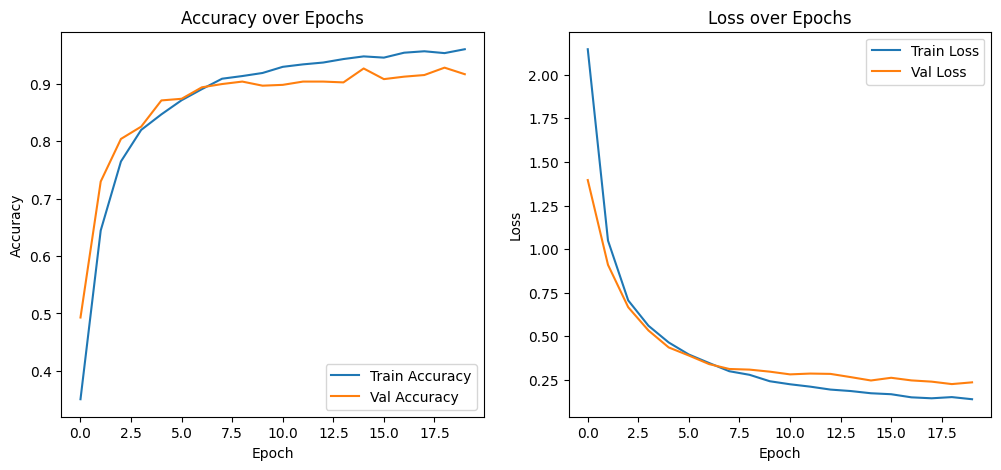

In [3]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()